In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, create_optimizer
from transformers.keras_callbacks import KerasMetricCallback

In [ ]:
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow Version: 2.19.0
GPU Available: True


In [ ]:
# rusentitweet_full_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_full.csv'
# rusentitweet_train_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_train.csv'
# rusentitweet_test_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_test.csv'

In [ ]:
MODEL_NAME = "DeepPavlov/rubert-base-cased"
BATCH_SIZE = 16
NUM_EPOCHS = 3
MAX_LENGTH = 128
LEARNING_RATE = 2e-5

rusentitweet_train_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_train.csv'
rusentitweet_test_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_test.csv'

print(f"Model: {MODEL_NAME}")
print(f"Batch size: {BATCH_SIZE}")

Model: DeepPavlov/rubert-base-cased
Batch size: 16


In [ ]:
print("Загрузка данных...")

df_train_full = pd.read_csv(rusentitweet_train_path)
df_test = pd.read_csv(rusentitweet_test_path)

df_train_full = df_train_full[df_train_full['label'] != 'skip']
df_test = df_test[df_test['label'] != 'skip']

train_df, valid_df = train_test_split(
    df_train_full,
    test_size=0.1,
    random_state=42,
    stratify=df_train_full['label']
)

print(f"Размеры выборок:")
print(f"Train: {len(train_df)}")
print(f"Valid: {len(valid_df)}")
print(f"Test:  {len(df_test)}")

Загрузка данных...
Размеры выборок:
Train: 8315
Valid: 924
Test:  2310


In [ ]:
label_list = sorted(list(set(train_df['label'])))
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}

print(f"Mapping классов: {label2id}")
NUM_LABELS = len(label_list)

def map_labels(df):
    df_copy = df.copy()
    df_copy['label'] = df_copy['label'].map(label2id)
    return df_copy

train_df = map_labels(train_df)
valid_df = map_labels(valid_df)
test_df_mapped = map_labels(df_test)

dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df.reset_index(drop=True)),
    'validation': Dataset.from_pandas(valid_df.reset_index(drop=True)),
    'test': Dataset.from_pandas(test_df_mapped.reset_index(drop=True))
})

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)
print("Токенизация завершена.")

Mapping классов: {'negative': 0, 'neutral': 1, 'positive': 2, 'speech': 3}


Map:   0%|          | 0/8315 [00:00<?, ? examples/s]

Map:   0%|          | 0/924 [00:00<?, ? examples/s]

Map:   0%|          | 0/2310 [00:00<?, ? examples/s]

Токенизация завершена.


In [ ]:
data_collator = None

def prepare_tf_dataset(hf_dataset, shuffle=False):
    return hf_dataset.to_tf_dataset(
        columns=["input_ids", "token_type_ids", "attention_mask"],
        label_cols=["label"],
        shuffle=shuffle,
        batch_size=BATCH_SIZE,
        collate_fn=data_collator
    )

tf_train = prepare_tf_dataset(tokenized_datasets["train"], shuffle=True)
tf_validation = prepare_tf_dataset(tokenized_datasets["validation"], shuffle=False)
tf_test = prepare_tf_dataset(tokenized_datasets["test"], shuffle=False)

print("TensorFlow Datasets готовы к загрузке в модель.")

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


TensorFlow Datasets готовы к загрузке в модель.


In [ ]:

total_train_steps = len(tf_train) * NUM_EPOCHS
optimizer, schedule = create_optimizer(
    init_lr=LEARNING_RATE,
    num_train_steps=total_train_steps,
    num_warmup_steps=0,
    weight_decay_rate=0.01
)

model = TFAutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    from_pt=True
)

model.compile(optimizer=optimizer, metrics=["accuracy"])

print("Начинаем обучение...")
history = model.fit(
    tf_train,
    validation_data=tf_validation,
    epochs=NUM_EPOCHS
)

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should p

Начинаем обучение...
Epoch 1/3
520/520 [==============================] - 288s 493ms/step - loss: 0.8725 - accuracy: 0.6256 - val_loss: 0.7150 - val_accuracy: 0.6959
Epoch 2/3
520/520 [==============================] - 258s 496ms/step - loss: 0.5554 - accuracy: 0.7906 - val_loss: 0.6750 - val_accuracy: 0.7165
Epoch 3/3
520/520 [==============================] - 258s 495ms/step - loss: 0.3505 - accuracy: 0.8744 - val_loss: 0.7629 - val_accuracy: 0.7154


In [ ]:
print("Генерация прогнозов на тестовой выборке...")
predictions = model.predict(tf_test)
logits = predictions.logits
predicted_ids = np.argmax(logits, axis=-1)

true_ids = tokenized_datasets["test"]["label"]

predicted_labels = [id2label[i] for i in predicted_ids]
true_labels = [id2label[i] for i in true_ids]

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(true_labels, predicted_labels))

acc = accuracy_score(true_ids, predicted_ids)
f1_macro = f1_score(true_ids, predicted_ids, average='macro')

print(f"Global Accuracy: {acc:.4f}")
print(f"Macro F1-Score:  {f1_macro:.4f}")

Генерация прогнозов на тестовой выборке...
145/145 [==============================] - 24s 149ms/step

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    negative       0.72      0.70      0.71       660
     neutral       0.78      0.77      0.77      1068
    positive       0.64      0.70      0.67       483
      speech       0.77      0.71      0.74        99

    accuracy                           0.73      2310
   macro avg       0.73      0.72      0.72      2310
weighted avg       0.73      0.73      0.73      2310

Global Accuracy: 0.7320
Macro F1-Score:  0.7229


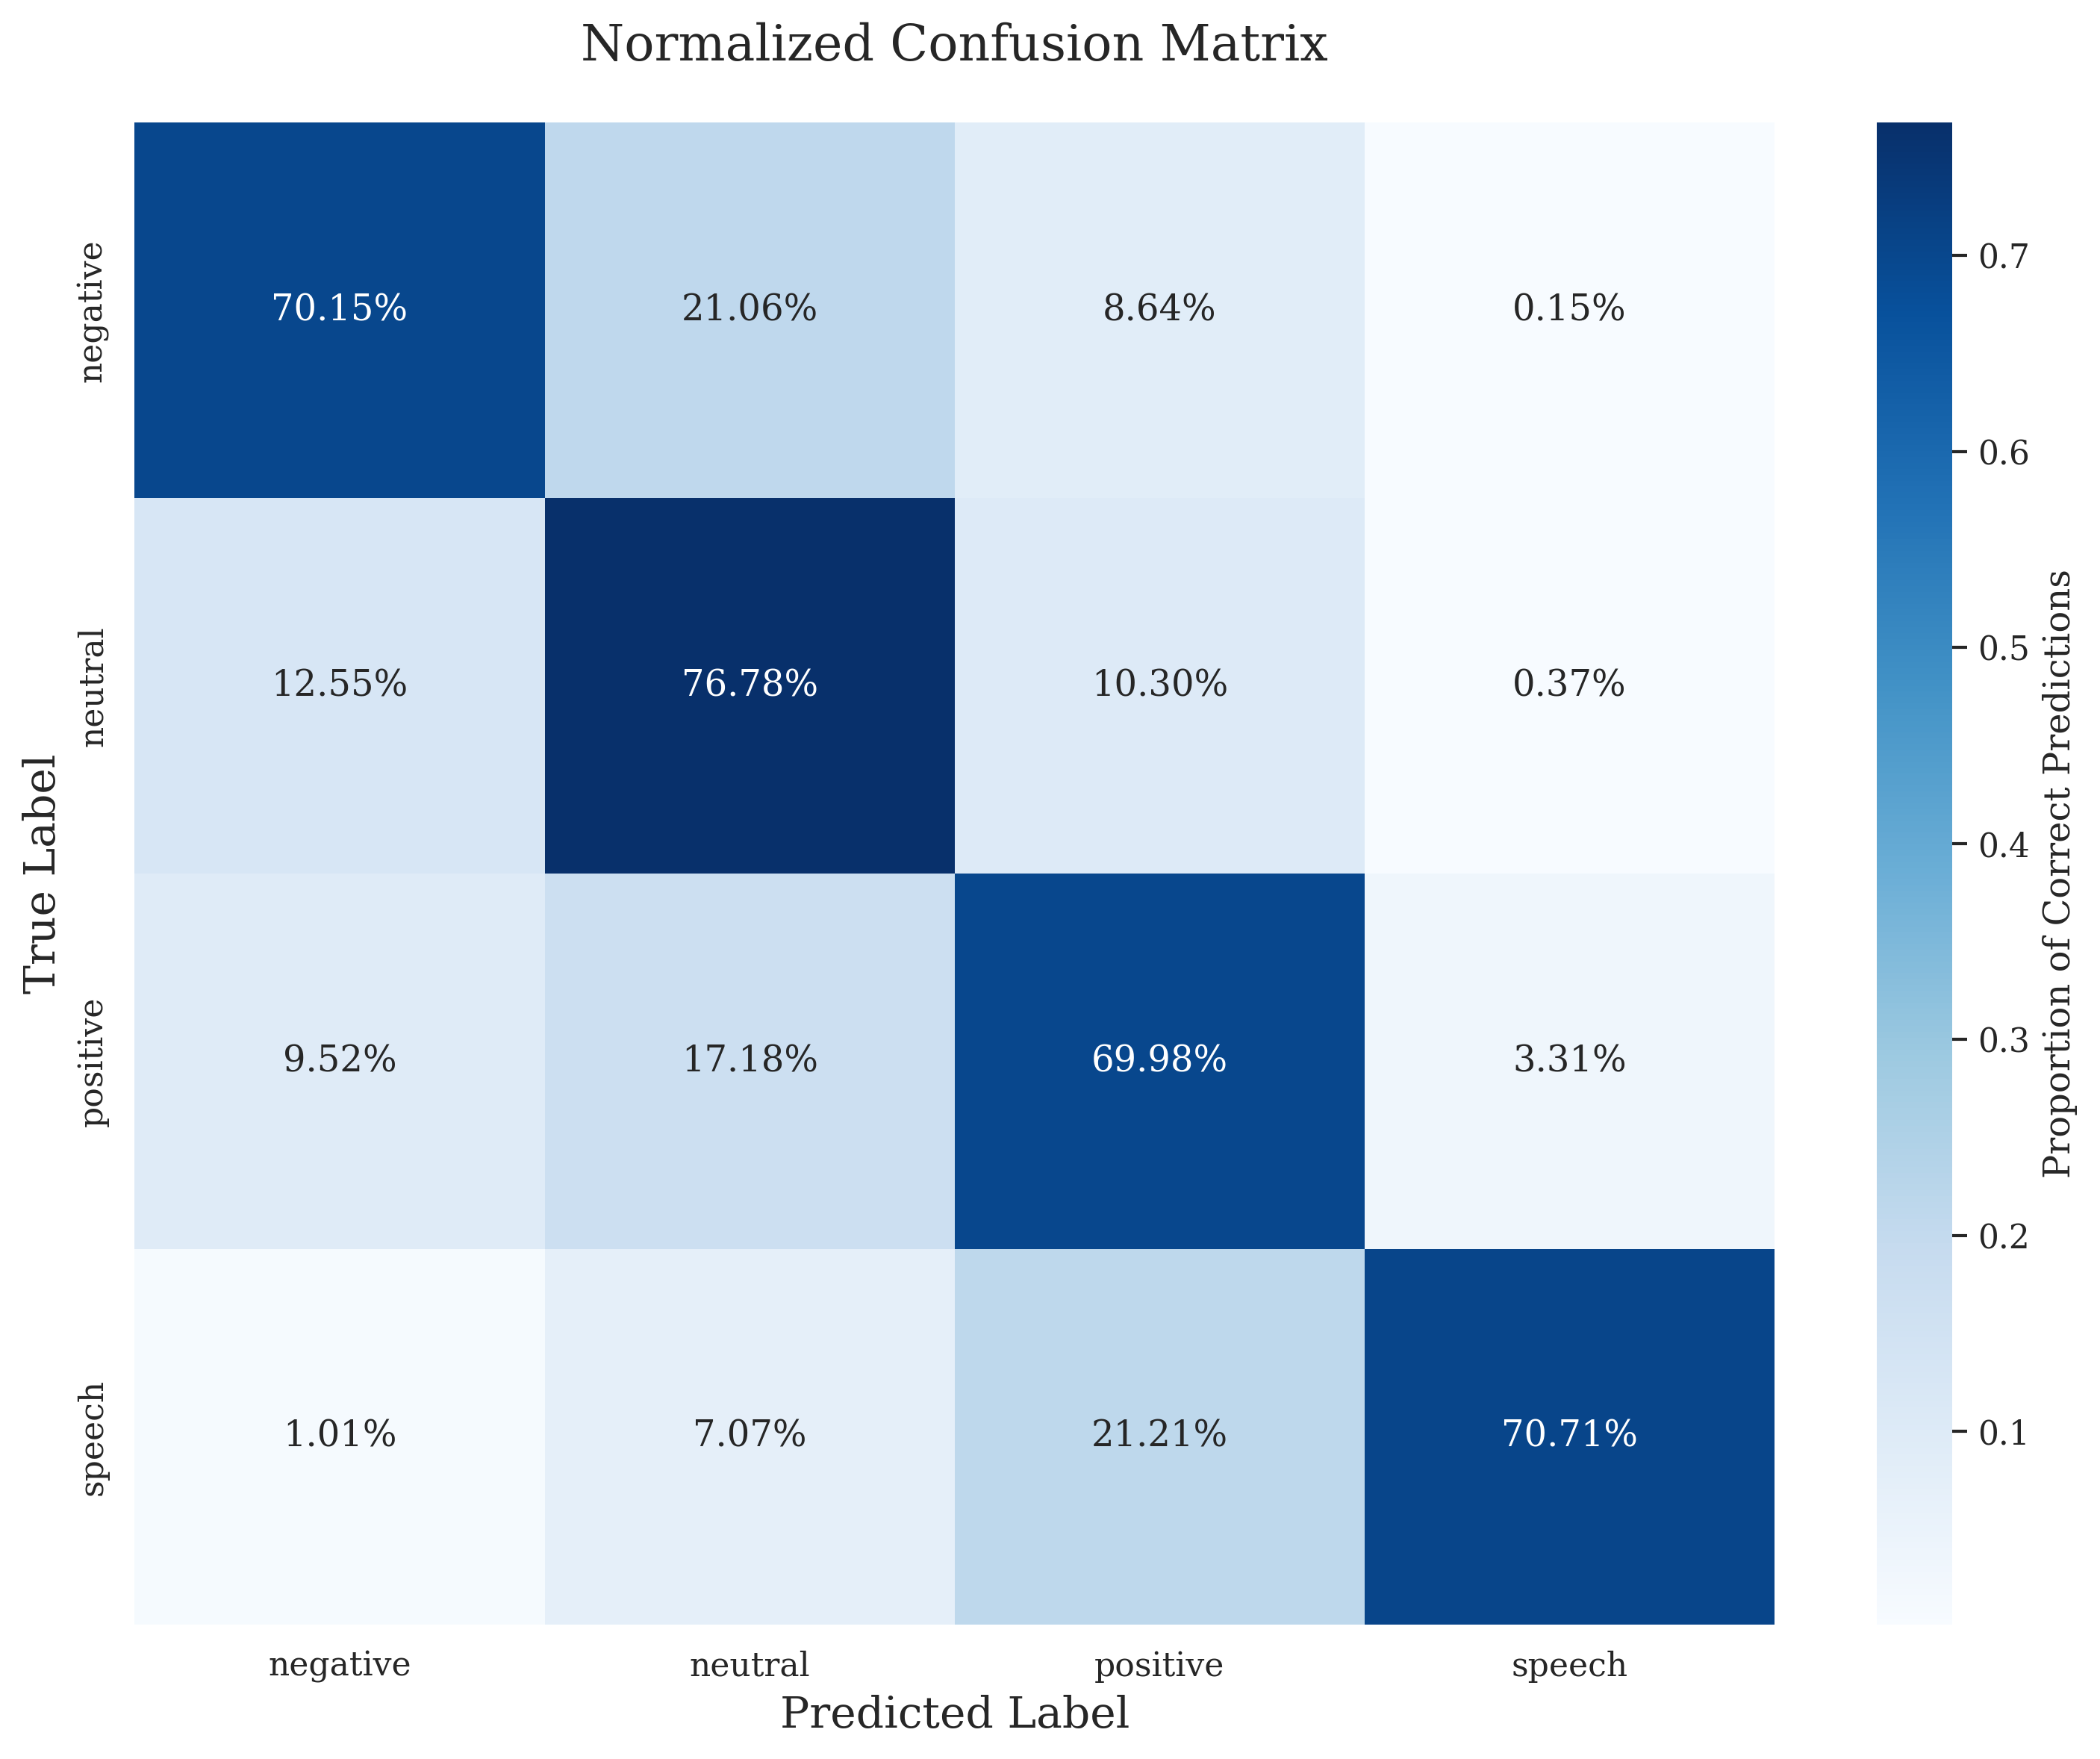

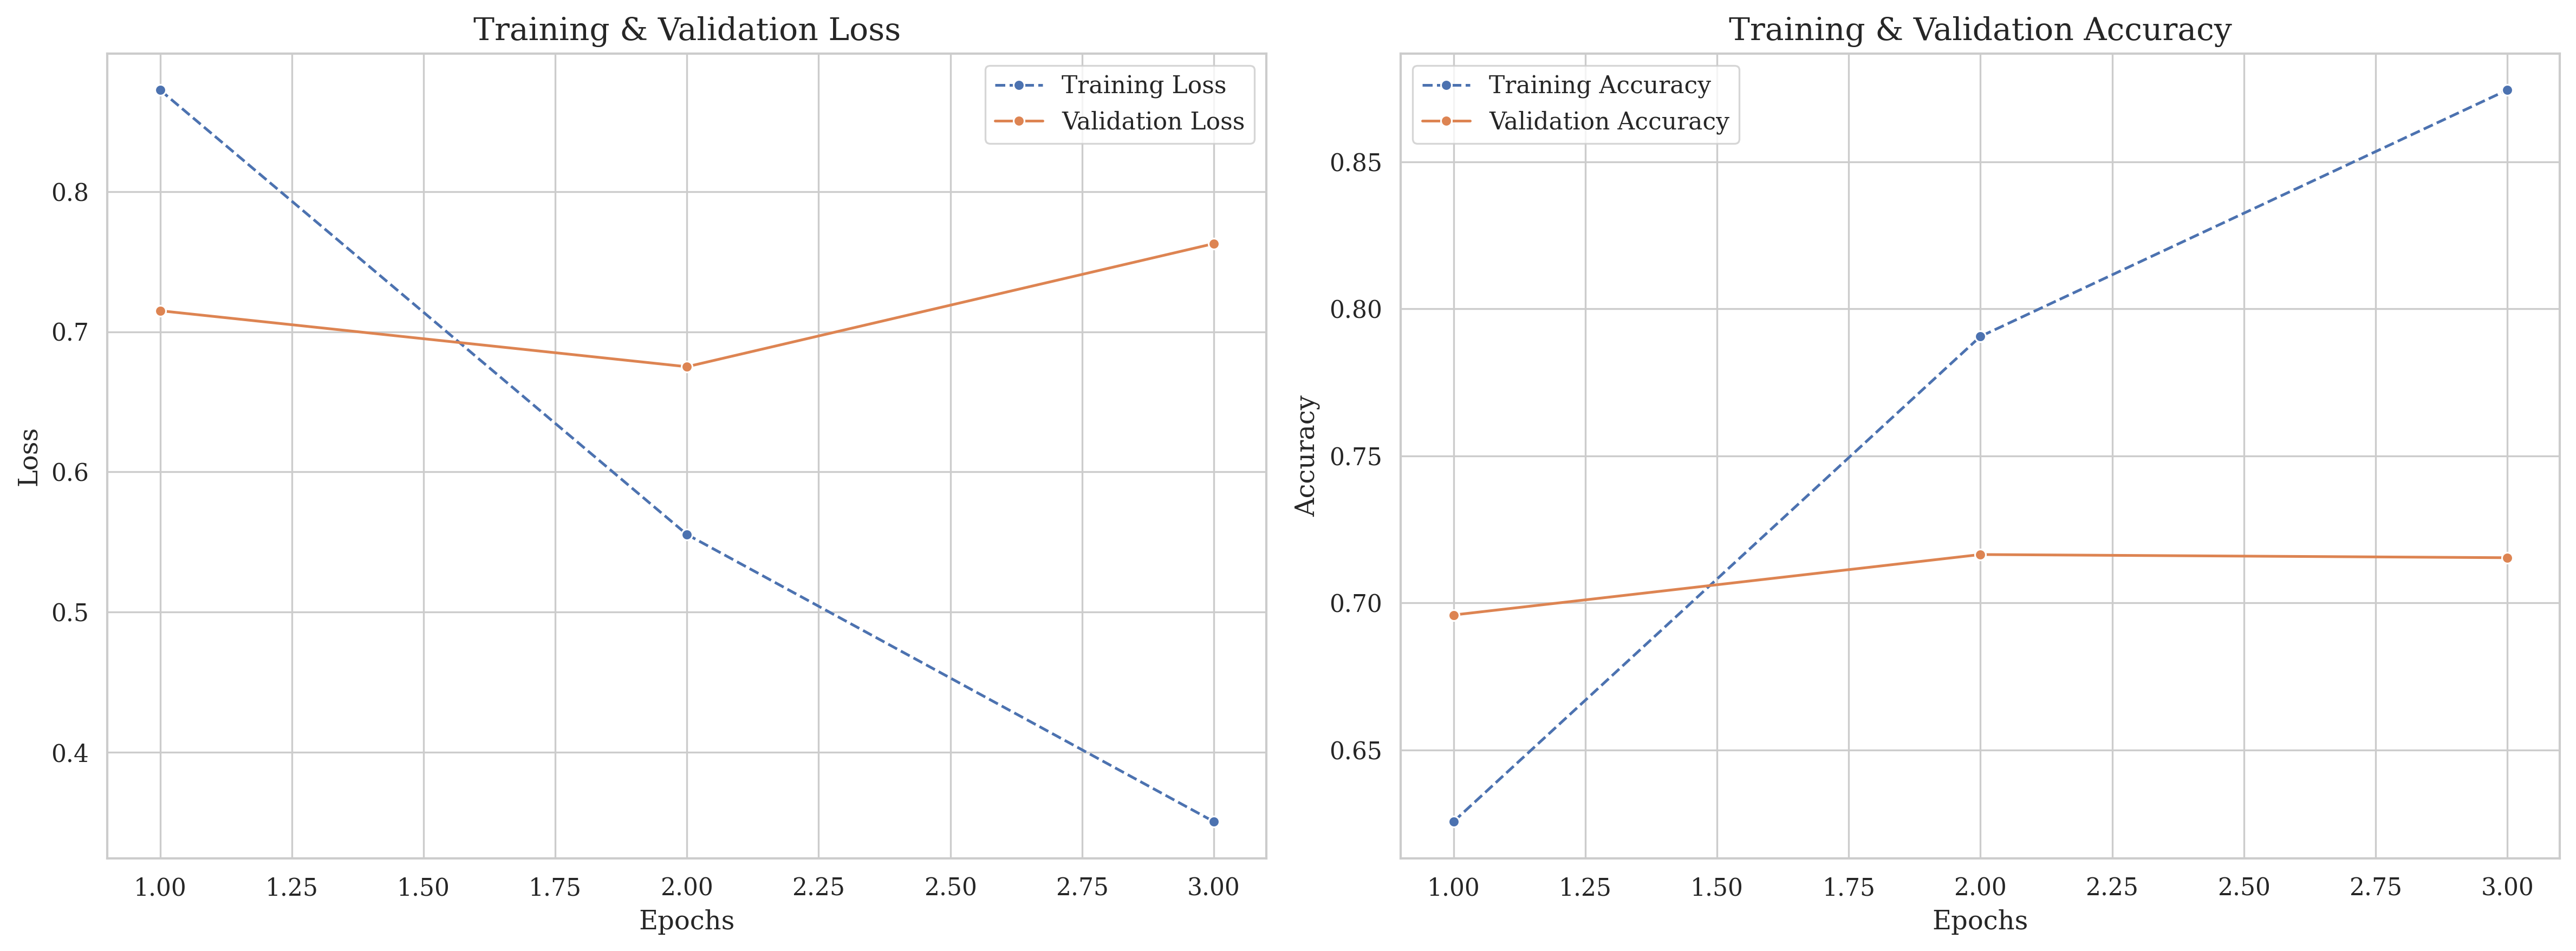

<function __main__.plot_class_metrics(y_true, y_pred, labels)>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 300

def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')

    plt.figure(figsize=(10, 8))
    heatmap = sns.heatmap(
        cm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={'label': 'Proportion of Correct Predictions'}
    )

    plt.title('Normalized Confusion Matrix', fontsize=16, pad=20)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(true_labels, predicted_labels, labels=label_list)



def plot_training_history(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(loss) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


    sns.lineplot(x=epochs, y=loss, label='Training Loss', ax=ax1, marker='o', linestyle='--')
    sns.lineplot(x=epochs, y=val_loss, label='Validation Loss', ax=ax1, marker='o')
    ax1.set_title('Training & Validation Loss', fontsize=14)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()


    sns.lineplot(x=epochs, y=acc, label='Training Accuracy', ax=ax2, marker='o', linestyle='--')
    sns.lineplot(x=epochs, y=val_acc, label='Validation Accuracy', ax=ax2, marker='o')
    ax2.set_title('Training & Validation Accuracy', fontsize=14)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300)
    plt.show()


if 'history' in globals():
    plot_training_history(history)
else:
    print("Объект history не найден. Запустите обучение (model.fit) перед построением графика.")



from sklearn.metrics import precision_recall_fscore_support

def plot_class_metrics(y_true, y_pred, labels):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=labels)

    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width, precision, width, label='Precision', color='#6c757d')
    rects2 = ax.bar(x, recall, width, label='Recall', color='#17a2b8')
    rects3 = ax.bar(x + width, f1, width, label='F1-Score', color='#007bff')

    ax.set_ylabel('Score')
    ax.set_title('Metrics per Class', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

    plt.tight_layout()
    plt.savefig('class_metrics.png', dpi=300)
    plt.show()

plot_class_metrics

In [ ]:
test_texts = dataset['test']['text']
true_labels_decoded = true_labels
pred_labels_decoded = predicted_labels

results_df = pd.DataFrame({
    'text': test_texts,
    'true_label': true_labels_decoded,
    'pred_label': pred_labels_decoded
})

errors = results_df[results_df['true_label'] != results_df['pred_label']]

speech_as_positive = errors[(errors['true_label'] == 'speech') & (errors['pred_label'] == 'positive')]

negative_as_neutral = errors[(errors['true_label'] == 'negative') & (errors['pred_label'] == 'neutral')]

print("--- ПРИМЕРЫ ОШИБОК: SPEECH -> POSITIVE ---")
for i, row in speech_as_positive.head(3).iterrows():
    print(f"Текст: {row['text']}")
    print(f"Прогноз: {row['pred_label']} | Факт: {row['true_label']}\n")

print("--- ПРИМЕРЫ ОШИБОК: NEGATIVE -> NEUTRAL ---")
for i, row in negative_as_neutral.head(3).iterrows():
    print(f"Текст: {row['text']}")
    print(f"Прогноз: {row['pred_label']} | Факт: {row['true_label']}\n")

--- ПРИМЕРЫ ОШИБОК: SPEECH -> POSITIVE ---
Текст: @ilowyl о нет :(( поправляйся скорее!! 🥺
Прогноз: positive | Факт: speech

Текст: @DooLeeHyung Если хочешь могу платить но если это комплимент в сторону моего гарема то спасибо🥺💋💋
Прогноз: positive | Факт: speech

Текст: посвящаю свое 25к твит девушкам басистам поп панку и

фену, люстре, синни, челам из фд Маркиплаера и Шона и вообще

лбблб вас всех😘😘
Прогноз: positive | Факт: speech

--- ПРИМЕРЫ ОШИБОК: NEGATIVE -> NEUTRAL ---
Текст: (пушка на Караульной горе больше не стреляет БА-БАХ!!) #красноярск
Прогноз: neutral | Факт: negative

Текст: @niemalsnoch @veritas_z ну кто ты и кто залина. камон
Прогноз: neutral | Факт: negative

Текст: от красных носков неприятно несёт гетеронормативностью
Прогноз: neutral | Факт: negative

